In [67]:
import numpy as np, pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

import warnings
warnings.filterwarnings('ignore')

In [68]:

url = "https://raw.githubusercontent.com/everyday-data-science/Data_Science_Projects/main/Insights%20from%20City%20Supply%20and%20Demand/Data/dataset_1.csv"

df = pd.read_csv(url)

df.sample(5)

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
42,NaN,1,6,0,1,1,2
201,NaN,16,20,5,3,3,6
332,NaN,3,3,3,0,1,0
30,NaN,13,11,2,1,1,7
128,NaN,15,31,15,3,8,5


In [69]:
df.shape

(336, 7)

In [70]:
df.isnull().sum()

,0
Date,321
Time (Local),0
Eyeballs,0
Zeroes,0
Completed Trips,0
Requests,0
Unique Drivers,0


In [71]:
df["Date"].ffill(axis=0, inplace=True)

In [72]:
df.isnull().sum()


,0
Date,0
Time (Local),0
Eyeballs,0
Zeroes,0
Completed Trips,0
Requests,0
Unique Drivers,0


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              336 non-null    object
 1   Time (Local)      336 non-null    int64 
 2   Eyeballs          336 non-null    int64 
 3   Zeroes            336 non-null    int64 
 4   Completed Trips   336 non-null    int64 
 5   Requests          336 non-null    int64 
 6   Unique Drivers    336 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 18.5+ KB


Q1: Which date had the most completed trips during the two week period?

In [75]:

df.groupby('Date').agg(Total_Completed=('Completed Trips ','sum')).reset_index().sort_values(by='Total_Completed', ascending=False).head(1)

,Date,Total_Completed
12,22-Sep-12,248


  Q2: What was the highest number of completed trips within a 24 hour period?



In [76]:
df.head()

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers
0,10-Sep-12,7,5,0,2,2,9
1,10-Sep-12,8,6,0,2,2,14
2,10-Sep-12,9,8,3,0,0,14
3,10-Sep-12,10,9,2,0,1,14
4,10-Sep-12,11,11,1,4,4,11


In [77]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time (Local)'].astype(str) + ':00:00')
df.head()

,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,datetime
0,10-Sep-12,7,5,0,2,2,9,2012-09-10 07:00:00
1,10-Sep-12,8,6,0,2,2,14,2012-09-10 08:00:00
2,10-Sep-12,9,8,3,0,0,14,2012-09-10 09:00:00
3,10-Sep-12,10,9,2,0,1,14,2012-09-10 10:00:00
4,10-Sep-12,11,11,1,4,4,11,2012-09-10 11:00:00


In [78]:
df.columns

Index(['Date', 'Time (Local)', 'Eyeballs ', 'Zeroes ', 'Completed Trips ',
       'Requests ', 'Unique Drivers', 'datetime'],
      dtype='object')

In [79]:
df.set_index('datetime', inplace=True)
df_rolling_sum = df['Completed Trips '].rolling('24H').sum().shift(-23)

In [80]:
df_rolling_sum.sort_values(ascending=False)

,Completed Trips
datetime,
2012-09-21 17:00:00,278.0
2012-09-21 16:00:00,274.0
2012-09-21 20:00:00,261.0
2012-09-22 04:00:00,260.0
2012-09-22 08:00:00,260.0
...,...
2012-09-24 02:00:00,NaN
2012-09-24 03:00:00,NaN
2012-09-24 04:00:00,NaN


Q3: Which hour of the day had the most requests during the two week period?


In [81]:
df.groupby('Time (Local)').agg(
    Total_Requests=('Requests ', 'sum')
).reset_index().sort_values(
    by='Total_Requests',
    ascending=False
).head(1)


,Time (Local),Total_Requests
23,23,184


Q4: What percentages of all zeroes during the two week period occurred on weekend (Friday at 5 pm to Sunday at 3 am)?

In [86]:
df = df.reset_index()

# Extract the day of the week
df['day_of_week'] = df['datetime'].dt.day_name()
df['day'] = df['datetime'].dt.dayofweek
df.head()

,level_0,index,datetime,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day
0,0,0,2012-09-10 07:00:00,10-Sep-12,7,5,0,2,2,9,Monday,0
1,1,1,2012-09-10 08:00:00,10-Sep-12,8,6,0,2,2,14,Monday,0
2,2,2,2012-09-10 09:00:00,10-Sep-12,9,8,3,0,0,14,Monday,0
3,3,3,2012-09-10 10:00:00,10-Sep-12,10,9,2,0,1,14,Monday,0
4,4,4,2012-09-10 11:00:00,10-Sep-12,11,11,1,4,4,11,Monday,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   level_0           336 non-null    int64         
 1   index             336 non-null    int64         
 2   datetime          336 non-null    datetime64[ns]
 3   Date              336 non-null    object        
 4   Time (Local)      336 non-null    int64         
 5   Eyeballs          336 non-null    int64         
 6   Zeroes            336 non-null    int64         
 7   Completed Trips   336 non-null    int64         
 8   Requests          336 non-null    int64         
 9   Unique Drivers    336 non-null    int64         
 10  day_of_week       336 non-null    object        
 11  day               336 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(8), object(2)
memory usage: 30.3+ KB


In [88]:
df['hour_two_digit'] = df['Time (Local)'].astype(str).str.zfill(2)
df.head()

,level_0,index,datetime,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day,hour_two_digit
0,0,0,2012-09-10 07:00:00,10-Sep-12,7,5,0,2,2,9,Monday,0,07
1,1,1,2012-09-10 08:00:00,10-Sep-12,8,6,0,2,2,14,Monday,0,08
2,2,2,2012-09-10 09:00:00,10-Sep-12,9,8,3,0,0,14,Monday,0,09
3,3,3,2012-09-10 10:00:00,10-Sep-12,10,9,2,0,1,14,Monday,0,10
4,4,4,2012-09-10 11:00:00,10-Sep-12,11,11,1,4,4,11,Monday,0,11


In [89]:
df[(df['day'].astype('str')+df['hour_two_digit']).astype('int').between(417,602)]['Zeroes '].sum()

np.int64(641)

In [90]:
 df['Zeroes '].sum()

np.int64(1429)

In [91]:
round(df[(df['day'].astype('str')+df['hour_two_digit']).astype('int').between(417,602)]['Zeroes '].sum() / df['Zeroes '].sum() * 100.0,2)


np.float64(44.86)

Answer: 44.86 %


Q5: What is the weighted average ratio of completed trips per driver during the two week period?



In [92]:
df['ratio'] = df['Completed Trips ']/df['Unique Drivers']
df.head()

,level_0,index,datetime,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day,hour_two_digit,ratio
0,0,0,2012-09-10 07:00:00,10-Sep-12,7,5,0,2,2,9,Monday,0,07,0.222222
1,1,1,2012-09-10 08:00:00,10-Sep-12,8,6,0,2,2,14,Monday,0,08,0.142857
2,2,2,2012-09-10 09:00:00,10-Sep-12,9,8,3,0,0,14,Monday,0,09,0.000000
3,3,3,2012-09-10 10:00:00,10-Sep-12,10,9,2,0,1,14,Monday,0,10,0.000000
4,4,4,2012-09-10 11:00:00,10-Sep-12,11,11,1,4,4,11,Monday,0,11,0.363636


In [93]:
df[df['ratio'].isnull()==True].head()

,level_0,index,datetime,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day,hour_two_digit,ratio
22,22,22,2012-09-11 05:00:00,11-Sep-12,5,1,1,0,0,0,Tuesday,1,05,NaN
43,43,43,2012-09-12 02:00:00,12-Sep-12,2,3,3,0,1,0,Wednesday,2,02,NaN
44,44,44,2012-09-12 03:00:00,12-Sep-12,3,2,2,0,0,0,Wednesday,2,03,NaN
45,45,45,2012-09-12 04:00:00,12-Sep-12,4,1,1,0,0,0,Wednesday,2,04,NaN
65,65,65,2012-09-13 00:00:00,13-Sep-12,0,11,11,0,2,0,Thursday,3,00,NaN


In [94]:
np.average(df[df['Unique Drivers'] != 0]['ratio'])

np.float64(0.4743397876937869)

In [95]:
# weighted average ratio
num = sum(df[df['Unique Drivers'] != 0]['ratio'] * df[df['Unique Drivers'] != 0]['Completed Trips '])
denom = sum(df[df['Unique Drivers'] != 0]['Completed Trips '])
round(num/denom,2)

0.83

Q6. In drafting a driver schedule in terms of 8 hours shifts, when are the busiest 8 consecutive hours over the two week period in terms of unique requests?


In [97]:
df.set_index('datetime', inplace=True)
df_rolling_sum = df['Requests '].rolling('8H').sum().shift(-7)

In [98]:
df_rolling_sum.sort_values(ascending=False).head(5)

,Requests
datetime,
2012-09-22 19:00:00,207.0
2012-09-21 17:00:00,207.0
2012-09-21 18:00:00,205.0
2012-09-22 18:00:00,202.0
2012-09-21 19:00:00,201.0


Asnwer: Busiest 8 consecutive hours with 207 unique requests each are:

September 21, 2012 5 PM - September 22, 2012 1 AM
September 22, 2012 7 PM - September 23, 2012 3 AM

**Q7: True or False: Driver supply always increases when demand increases during the two week period.**


In [99]:
df = df.reset_index()
df.head()

,datetime,level_0,index,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day,hour_two_digit,ratio
0,2012-09-10 07:00:00,0,0,10-Sep-12,7,5,0,2,2,9,Monday,0,07,0.222222
1,2012-09-10 08:00:00,1,1,10-Sep-12,8,6,0,2,2,14,Monday,0,08,0.142857
2,2012-09-10 09:00:00,2,2,10-Sep-12,9,8,3,0,0,14,Monday,0,09,0.000000
3,2012-09-10 10:00:00,3,3,10-Sep-12,10,9,2,0,1,14,Monday,0,10,0.000000
4,2012-09-10 11:00:00,4,4,10-Sep-12,11,11,1,4,4,11,Monday,0,11,0.363636


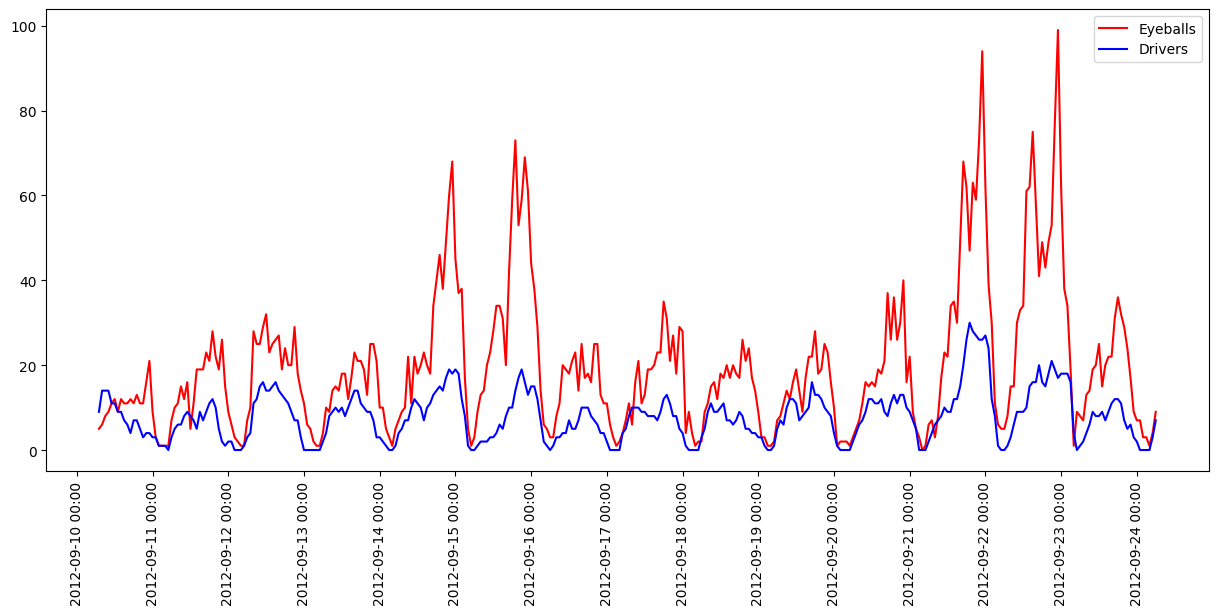

In [100]:
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'], df['Eyeballs '], color='red', label='Eyeballs')
plt.plot(df['datetime'], df['Unique Drivers'], color='blue', label='Drivers')
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.legend()
plt.xticks(rotation=90)
plt.show()


Asnwer: FALSE. Generally, driver supply increases when demand increases but NOT always.

**Q8: In which 72 hour period is the ratio of Zeroes to Eyeballs the highest?**


In [101]:
df.set_index('datetime', inplace=True)
df_rolling_sum = df['Zeroes '].rolling('72H').sum().shift(-71)
df_rolling_sum2 = df['Eyeballs '].rolling('72H').sum().shift(-71)

In [102]:
combined = pd.concat([df_rolling_sum, df_rolling_sum2], axis=1)
combined['ratio'] = combined['Zeroes ']/combined['Eyeballs ']
combined.sort_values(ascending=False, by='ratio').head(5)

,Zeroes,Eyeballs,ratio
datetime,,,
2012-09-15 05:00:00,438.0,1495.0,0.292977
2012-09-15 04:00:00,438.0,1499.0,0.292195
2012-09-15 06:00:00,437.0,1496.0,0.292112
2012-09-15 07:00:00,434.0,1495.0,0.290301
2012-09-15 03:00:00,436.0,1512.0,0.288360


Answer: Highest Zeroes to Eyeballs ratio is: September 15, 2012 5 AM - September 18, 2012 5 AM

**Q9: If you could add 5 drivers to any single hour of every day during the two week period, which hour should you add them to?3**

In [103]:

eye_vs_drivers = df.groupby('Time (Local)').agg(total_eyeballs=('Eyeballs ','sum'), total_drivers=('Unique Drivers','sum')).reset_index()
eye_vs_drivers['ratio'] = eye_vs_drivers['total_drivers']/eye_vs_drivers['total_eyeballs']
eye_vs_drivers.sort_values(by='ratio')


,Time (Local),total_eyeballs,total_drivers,ratio
23,23,488,119,0.243852
5,5,42,11,0.261905
22,22,492,144,0.292683
4,4,29,9,0.310345
0,0,339,111,0.327434
21,21,459,155,0.337691
2,2,170,62,0.364706
14,14,332,125,0.376506
18,18,447,174,0.389262
13,13,311,122,0.392283


Answer: Since, Hour 23 has the lowest driver availability to people looking for rides (Eyeballs), adding 5 more drivers to hour 23 would make most sense to improve that ratio.

**Q10: True or False: There is exactly two weeks of data in this analysis.**

In [104]:
df.head()

,level_0,index,Date,Time (Local),Eyeballs,Zeroes,Completed Trips,Requests,Unique Drivers,day_of_week,day,hour_two_digit,ratio
datetime,,,,,,,,,,,,,
2012-09-10 07:00:00,0,0,10-Sep-12,7,5,0,2,2,9,Monday,0,07,0.222222
2012-09-10 08:00:00,1,1,10-Sep-12,8,6,0,2,2,14,Monday,0,08,0.142857
2012-09-10 09:00:00,2,2,10-Sep-12,9,8,3,0,0,14,Monday,0,09,0.000000
2012-09-10 10:00:00,3,3,10-Sep-12,10,9,2,0,1,14,Monday,0,10,0.000000
2012-09-10 11:00:00,4,4,10-Sep-12,11,11,1,4,4,11,Monday,0,11,0.363636


In [107]:
df.index.min()

Timestamp('2012-09-10 07:00:00')

In [108]:
df.index.max()

Timestamp('2012-09-24 06:00:00')

Answer 10: TRUE, exactly 14 weeks between Sep 10, 2012 7 AM - Sep 24, 2012 7 AM.

**Q11: Looking at the data from all two weeks, which time might make the most sense to consider a true "end day" instead of midnight? (i.e when are supply and demand at both their natural minimums) **


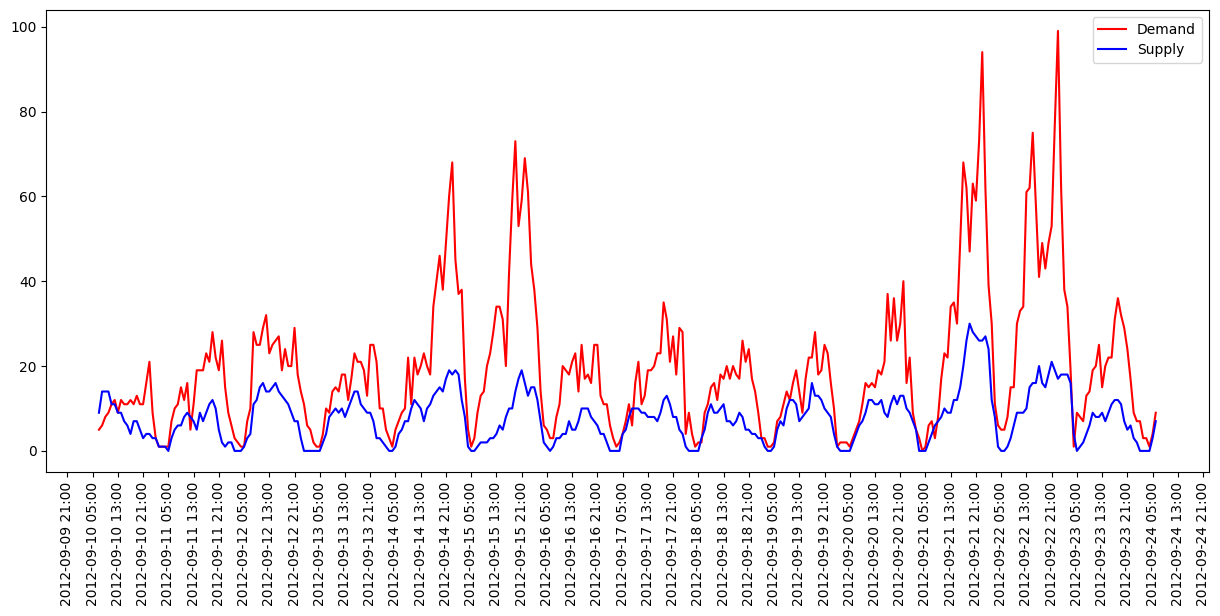

In [110]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Eyeballs '], color='red', label='Demand')
plt.plot(df.index, df['Unique Drivers'], color='blue', label='Supply')
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=8))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [111]:
minimum = df.groupby(['Date','Time (Local)']).agg(total_eyeballs=('Eyeballs ','sum'),total_drivers=('Unique Drivers','sum')).reset_index()


In [112]:

minimum['Rank_eye'] = minimum.groupby('Date')['total_eyeballs'].rank(ascending=True)
minimum['Rank_dri'] = minimum.groupby('Date')['total_drivers'].rank(ascending=True)
minimum

,Date,Time (Local),total_eyeballs,total_drivers,Rank_eye,Rank_dri
0,10-Sep-12,7,5,9,1.0,11.0
1,10-Sep-12,8,6,14,2.0,16.0
2,10-Sep-12,9,8,14,3.0,16.0
3,10-Sep-12,10,9,14,4.5,16.0
4,10-Sep-12,11,11,11,8.5,13.5
...,...,...,...,...,...,...
331,24-Sep-12,2,3,0,2.5,2.5
332,24-Sep-12,3,3,0,2.5,2.5
333,24-Sep-12,4,1,0,1.0,2.5
334,24-Sep-12,5,4,3,4.0,6.0


In [113]:
minimum[minimum['Rank_eye'].isin([1,2])]['Time (Local)'].value_counts(ascending=False)

,count
Time (Local),
4,6
7,2
5,2
3,2
8,1
6,1


In [114]:
minimum[minimum['Rank_dri'].isin([1,2])]['Time (Local)'].value_counts(ascending=False)

,count
Time (Local),
5,3
3,2
6,2
4,2
21,1
2,1


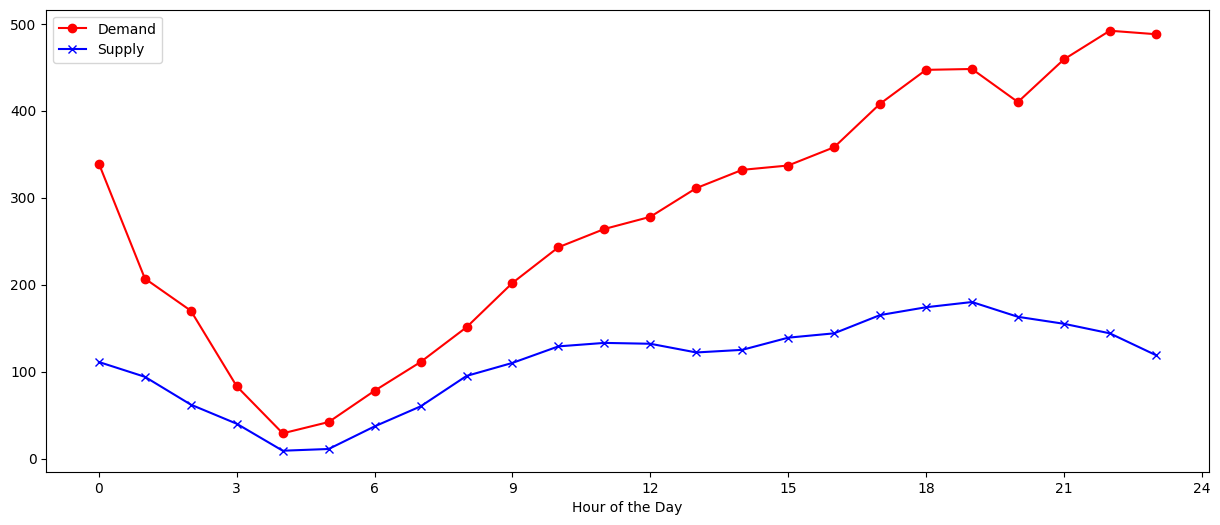

In [115]:
minimum2 = df.groupby(['Time (Local)']).agg(total_eyeballs=('Eyeballs ','sum'),total_drivers=('Unique Drivers','sum')).reset_index()
plt.figure(figsize=(15, 6))
plt.plot(minimum2['Time (Local)'], minimum2['total_eyeballs'], color='red', label='Demand', marker='o')
plt.plot(minimum2['Time (Local)'], minimum2['total_drivers'], color='blue', label='Supply', marker='x')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Hour of the Day')
plt.legend()
plt.show()

**Answer: From the graphs and rank analysis, we see the supply and demand is at minimum in early hours of morning, between 4 AM - 5 AM. Hence, instead of midnight, this should be the "true end" day.**
